In [6]:
#1. section ini berisi import dan data mentah
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

dataku = pd.read_csv("D:/Documents/Projectku/Data Analyst/Python/Projek Club Member/clean-club_member_info.csv")

In [2]:
# Set tema grafik
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

## EDA
. Univariate Analysis
age
marital status
city
state
job title
. Bivariate Analysis
age vs marital status
age vs job title
. Time Analysis
membership trend
. Conclusion
insight utama

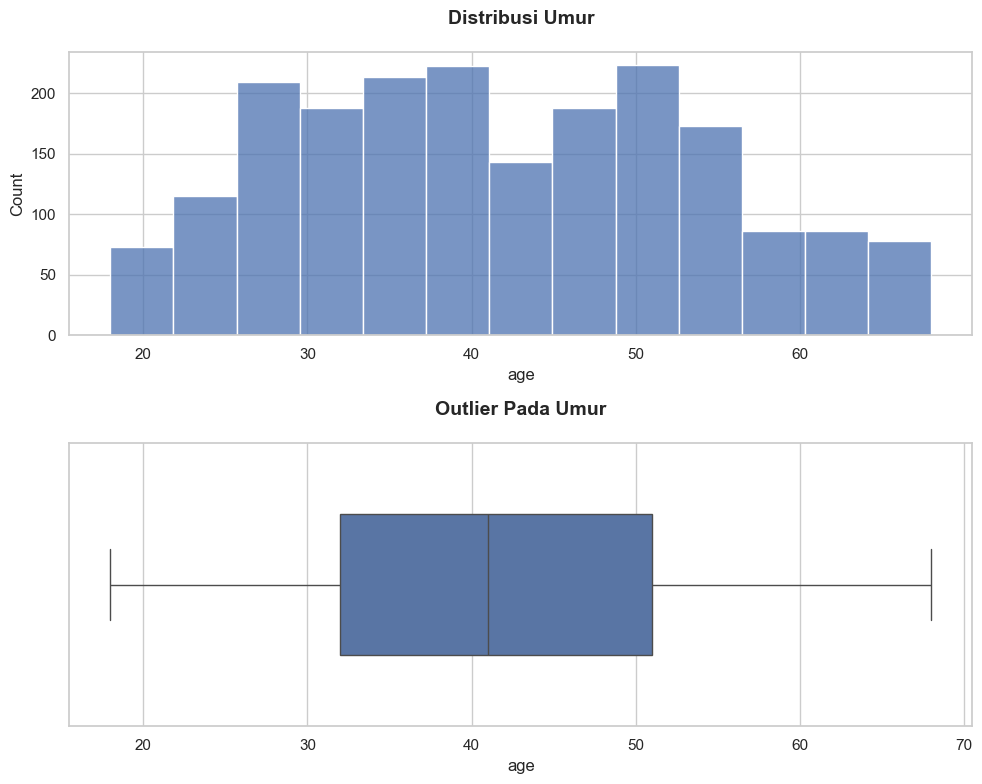

In [50]:
#Analisis Age
plt.figure(figsize=(10,8))

plt.subplot(2,1,1)
sns.histplot(data=dataku, x="age", bins=13)
plt.title("Distribusi Umur", fontsize=14, fontweight="bold", pad=20)
plt.xticks(range(20,70,10))

plt.subplot(2,1,2)
sns.boxplot(data=dataku, x="age", width=0.5)
plt.title("Outlier Pada Umur", fontsize=14, fontweight="bold", pad=20)

plt.tight_layout()

Text(0.5, 1.0, 'distribusi status pernikahan')

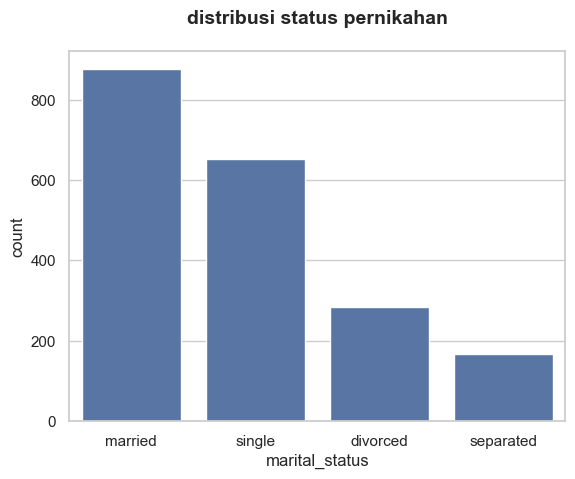

In [56]:
#marital_status (diurutkan dari terbanyak)
tb = dataku["marital_status"].value_counts().index
sns.countplot(data=dataku, x="marital_status", order=dataku["marital_status"].value_counts().index)
plt.title("distribusi status pernikahan", fontsize=14, fontweight="bold", pad=20)

Text(0.5, 1.0, 'distribusi 10 kota terbanyak')

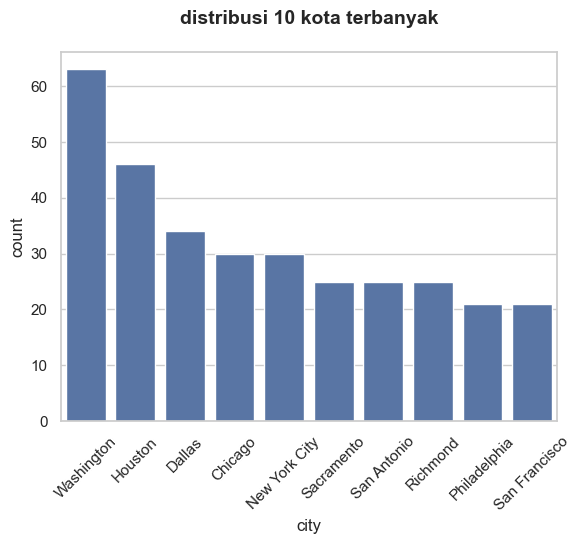

In [57]:
#city
sns.countplot(data=dataku, x="city", order=dataku["city"].value_counts().head(10).index)

plt.xticks(rotation=45)
plt.title("distribusi 10 kota terbanyak", fontsize=14, fontweight="bold", pad=20)

Text(0.5, 1.0, 'distribusi 10 negara bagian terbanyak')

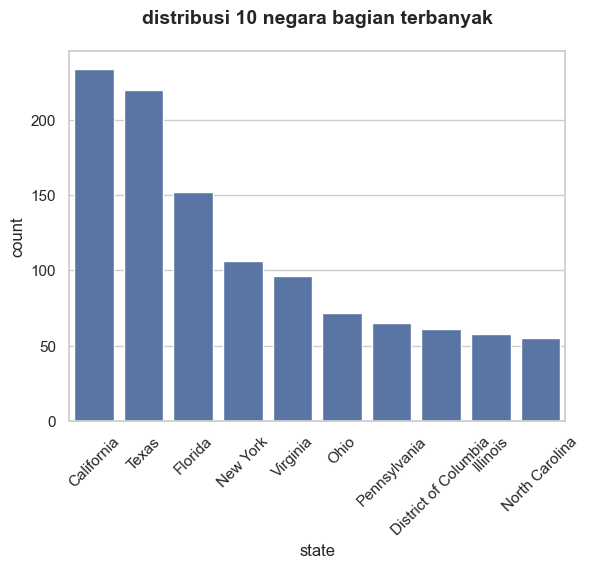

In [60]:
#state
sns.countplot(data=dataku, x="state", order=dataku["state"].value_counts().head(10).index)

plt.xticks(rotation=45)
plt.title("distribusi 10 negara bagian terbanyak", fontsize=14, fontweight="bold", pad=20)

Text(0.5, 1.0, 'distribusi 10 pekerjaan terbanyak')

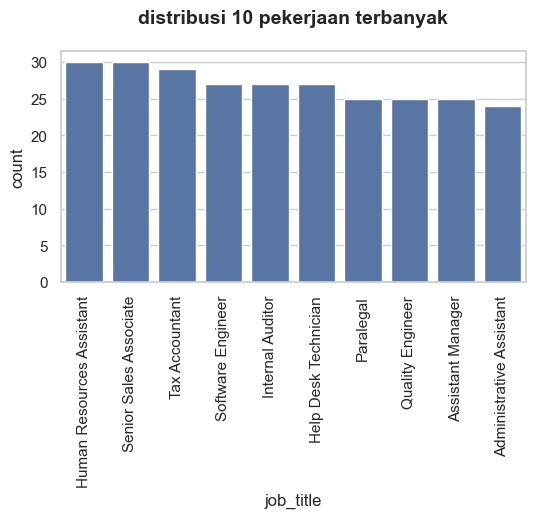

In [71]:
#job_title
plt.figure(figsize=(6,3))
sns.countplot(data=dataku, x="job_title", order=dataku["job_title"].value_counts().head(10).index)

plt.xticks(rotation=90)
plt.title("distribusi 10 pekerjaan terbanyak", fontsize=14, fontweight="bold", pad=20)

Memasuki ke bivariate analysis

Text(0.5, 1.0, 'distribusi umur berdasarkan status')

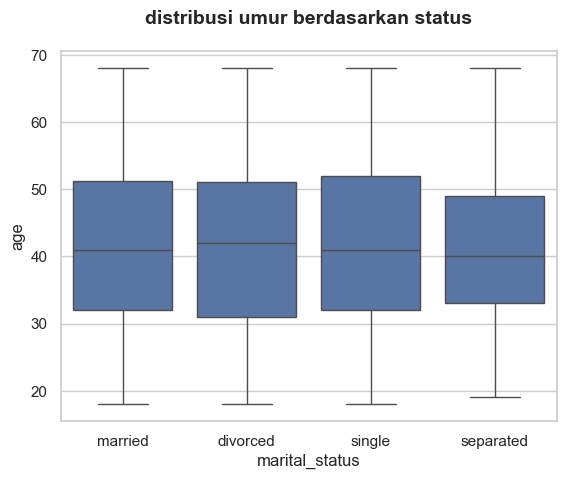

In [11]:
#age vs marital status
sns.boxplot(data=dataku, x="marital_status", y="age")
plt.title("distribusi umur berdasarkan status", fontsize=14, fontweight="bold", pad=20)

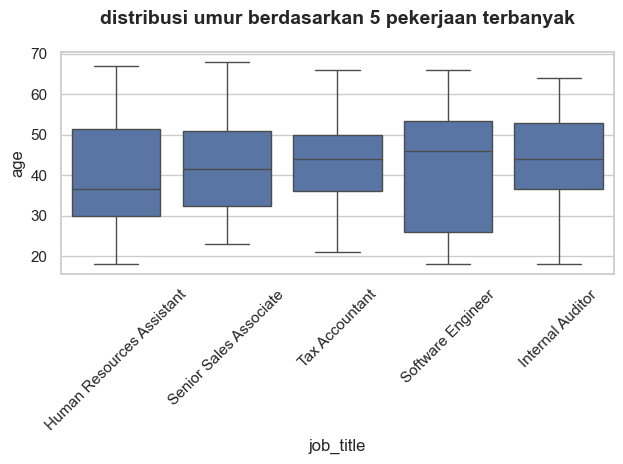

In [4]:
#age vs job title
sns.boxplot(data=dataku, x="job_title", y="age", order=dataku["job_title"].value_counts().head(5).index)
plt.title("distribusi umur berdasarkan 5 pekerjaan terbanyak", fontsize=14, fontweight="bold", pad=20)
plt.xticks(rotation=45)

plt.tight_layout()

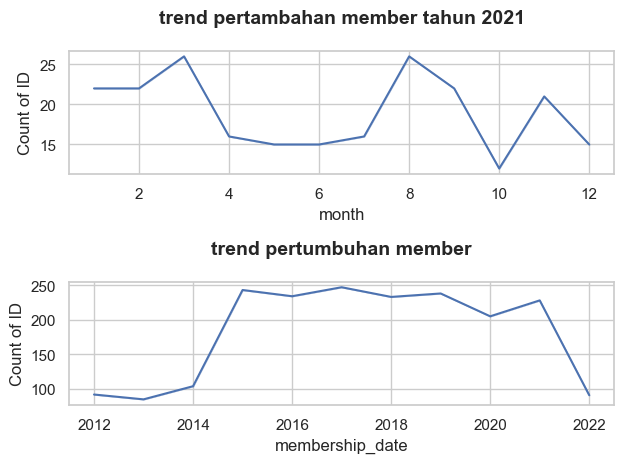

In [5]:
#membership_date
dataku["membership_date"] = pd.to_datetime(dataku["membership_date"])

plt.subplot(2,1,1)
data_2022 = dataku[dataku["membership_date"].dt.year == 2021].copy()
data_2022["month"] = data_2022["membership_date"].dt.month
sns.lineplot(data=data_2022, x="month", y="id", estimator=len)
plt.title("trend pertambahan member tahun 2021", fontsize=14, fontweight="bold", pad=20)
plt.ylabel("Count of ID")

plt.subplot(2,1,2)
sns.lineplot(data=dataku, x=dataku["membership_date"].dt.year, y="id", estimator=len)
plt.title("trend pertumbuhan member", fontsize=14, fontweight="bold", pad=20)
plt.ylabel("Count of ID")

plt.tight_layout()

In [7]:
# ambil 5 job title terbanyak
top5 = dataku["job_title"].value_counts().head(5).index

# filter data
filtered = dataku[dataku["job_title"].isin(top5)]

# buat boxplot
fig = px.box(
    filtered,
    x="job_title",
    y="age",
    color="job_title",
    title="Distribusi Umur Berdasarkan 5 Pekerjaan Terbanyak"
)

# rotate label x-axis
fig.update_layout(
    xaxis_tickangle=-45,
    title_font_size=20
)

fig.show()